   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 76.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

 Using device: cuda
 Found dataset at: /kaggle/input/deforestation-sat-data/dataset
 Starting training with 409 samples...
Epoch [1/20] | Train: 0.4323 | Val: 0.4428
  -->  Model Saved!
Epoch [2/20] | Train: 0.3177 | Val: 0.3543
  -->  Model Saved!
Epoch [3/20] | Train: 0.2820 | Val: 0.2430
  -->  Model Saved!
Epoch [4/20] | Train: 0.2688 | Val: 0.2135
  -->  Model Saved!
Epoch [5/20] | Train: 0.2453 | Val: 0.2440
Epoch [6/20] | Train: 0.2222 | Val: 0.1825
  -->  Model Saved!
Epoch [7/20] | Train: 0.2512 | Val: 0.1829
Epoch [8/20] | Train: 0.2172 | Val: 0.1891
Epoch [9/20] | Train: 0.1853 | Val: 0.1728
  -->  Model Saved!
Epoch [10/20] | Train: 0.1889 | Val: 0.1658
  -->  Model Saved!
Epoch [11/20] | Train: 0.2132 | Val: 0.1549
  -->  Model Saved!
Epoch [12/20] | Train: 0.2125 | Val: 0.1692
Epoch [13/20] | Train: 0.1909 | Val: 0.1491
  -->  Model Saved!
Epoch [14/20] | Train: 0.1727 | Val: 0.1651
Epoch [15/20] | Train: 0.1706 | Val: 0.1563
Epoch [16/20] | Train: 0.1666 | Val: 0.1648
Ep

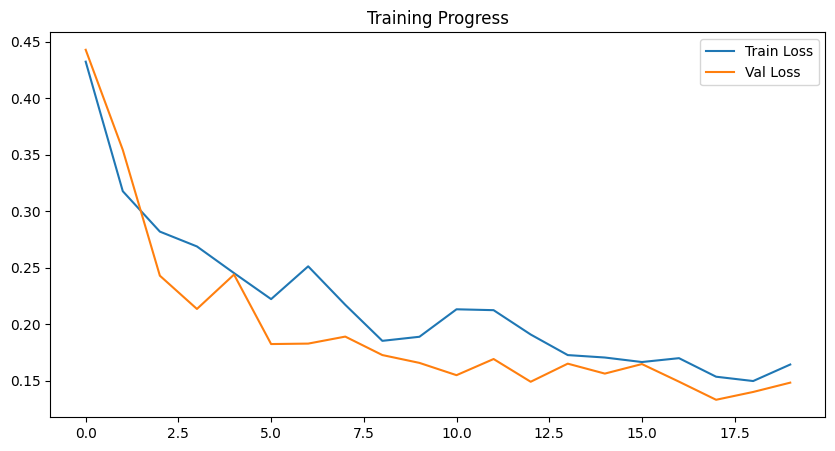

In [1]:
# --- CELL 1: INSTALL LIBRARIES ---

!pip install -q segmentation-models-pytorch rasterio

import os
import numpy as np
import torch
import rasterio
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import torch.nn.functional as F

# --- CONFIGURATION ---
# Kaggle Input Paths are tricky. 
# usually: /kaggle/input/<your-dataset-name>/dataset
# We will find it dynamically below.
BATCH_SIZE = 8          
EPOCHS = 20
LEARNING_RATE = 0.0001
ENCODER = "resnet34"    # Upgraded to ResNet34 since we have better GPUs
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f" Using device: {DEVICE}")

# --- FIND THE DATA PATH ---
# Kaggle puts datasets in /kaggle/input
# Let's find where your 'dataset' folder ended up
INPUT_ROOT = "/kaggle/input"
DATA_DIR = ""

for root, dirs, files in os.walk(INPUT_ROOT):
    if "train" in dirs and "val" in dirs:
        DATA_DIR = root
        print(f" Found dataset at: {DATA_DIR}")
        break

if not DATA_DIR:
    print(" Could not auto-find dataset! Please check 'Add Input' on the right.")
    # Fallback manually if needed:
    # DATA_DIR = "/kaggle/input/your-dataset-name-here/dataset"

# --- DATASET CLASS ---
class ChangeDetectionDataset(Dataset):
    def __init__(self, root_dir, split="train", image_size=(256, 256)):
        self.img_dir = os.path.join(root_dir, split, "images")
        self.mask_dir = os.path.join(root_dir, split, "masks")
        self.files = [f for f in os.listdir(self.mask_dir) if f.endswith("_mask.tif")]
        self.image_size = image_size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mask_name = self.files[idx]
        tid = mask_name.replace("_mask.tif", "")
        
        t1_path = os.path.join(self.img_dir, f"{tid}_t1.tif")
        t2_path = os.path.join(self.img_dir, f"{tid}_t2.tif")
        mask_path = os.path.join(self.mask_dir, mask_name)

        # 1. Load T1 (Normalize 0-1)
        with rasterio.open(t1_path) as src:
            t1 = src.read().astype("float32") / 10000.0
            
        # 2. Load T2 (Normalize 0-1)
        with rasterio.open(t2_path) as src:
            t2 = src.read().astype("float32") / 10000.0

        # 3. Stack -> (10, H, W)
        image = np.concatenate([t1, t2], axis=0)

        # 4. Load Mask
        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype("float32")
            mask[mask > 0] = 1.0 
        mask = np.expand_dims(mask, axis=0) # (1, H, W)

        # --- THE FIX: RESIZE TO FIXED DIMENSIONS ---
        # Convert to Tensor
        tensor_img = torch.from_numpy(image)
        tensor_mask = torch.from_numpy(mask)

        # Resize Image (Bilinear interpolation is best for continuous data)
        # interpolate expects (Batch, Channel, H, W), so we unsqueeze(0) then squeeze(0)
        tensor_img = F.interpolate(
            tensor_img.unsqueeze(0), 
            size=self.image_size, 
            mode='bilinear', 
            align_corners=False
        ).squeeze(0)

        # Resize Mask (Nearest Exact is MANDATORY for masks to keep values 0 or 1)
        tensor_mask = F.interpolate(
            tensor_mask.unsqueeze(0), 
            size=self.image_size, 
            mode='nearest'
        ).squeeze(0)

        return tensor_img, tensor_mask

# --- TRAINING LOOP ---
def train_model():
    if not DATA_DIR: return

    train_dataset = ChangeDetectionDataset(DATA_DIR, split="train")
    val_dataset = ChangeDetectionDataset(DATA_DIR, split="val")

    # Increased workers for Kaggle
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f" Starting training with {len(train_dataset)} samples...")

    # U-Net with 10 input channels
    model = smp.Unet(
        encoder_name=ENCODER, 
        encoder_weights=None, 
        in_channels=10, 
        classes=1, 
        activation=None
    )
    model.to(DEVICE)

    criterion = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float("inf")
    
    # History for plotting
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        
        for images, masks in train_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

        # Save to /kaggle/working (This is the output folder)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
            print("  -->  Model Saved!")

    # Plot results
    plt.figure(figsize=(10,5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title("Training Progress")
    plt.legend()
    plt.savefig("/kaggle/working/training_plot.png")
    plt.show()

if __name__ == "__main__":
    train_model()

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

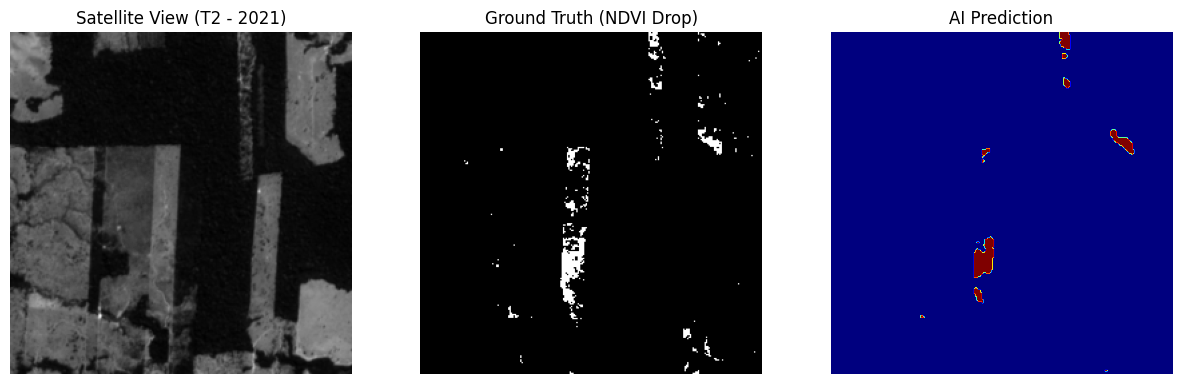

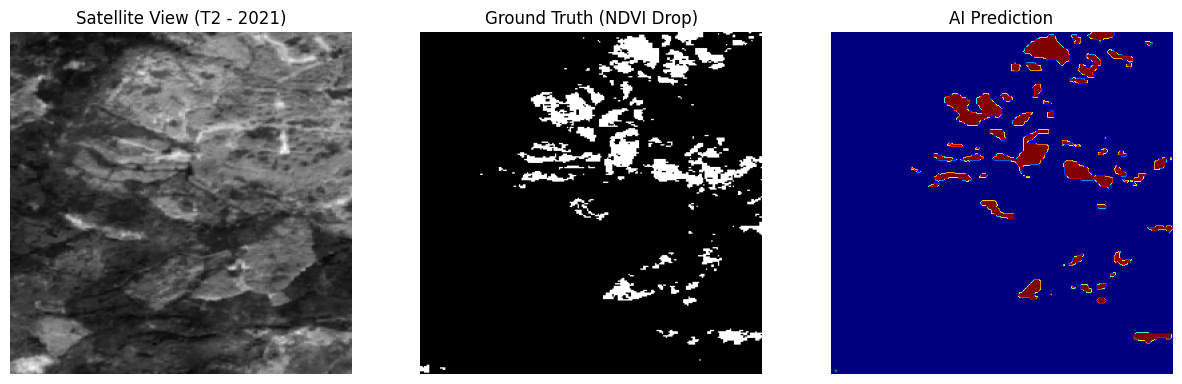

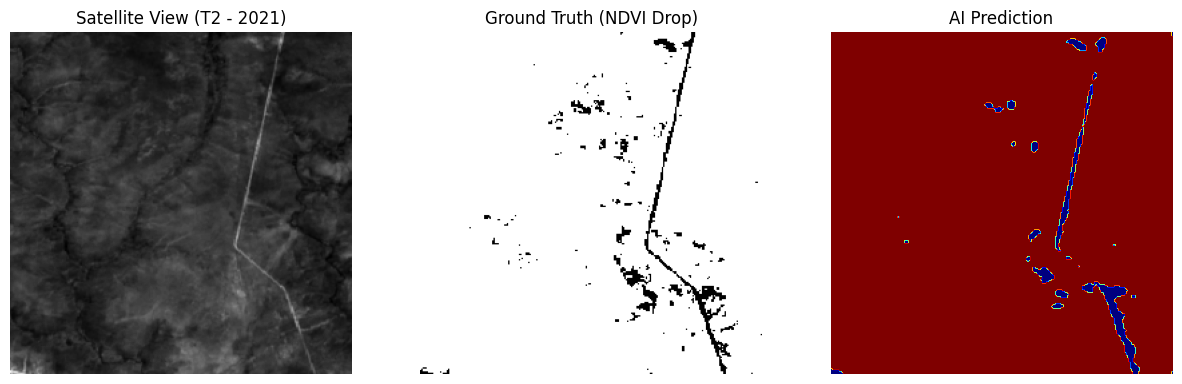

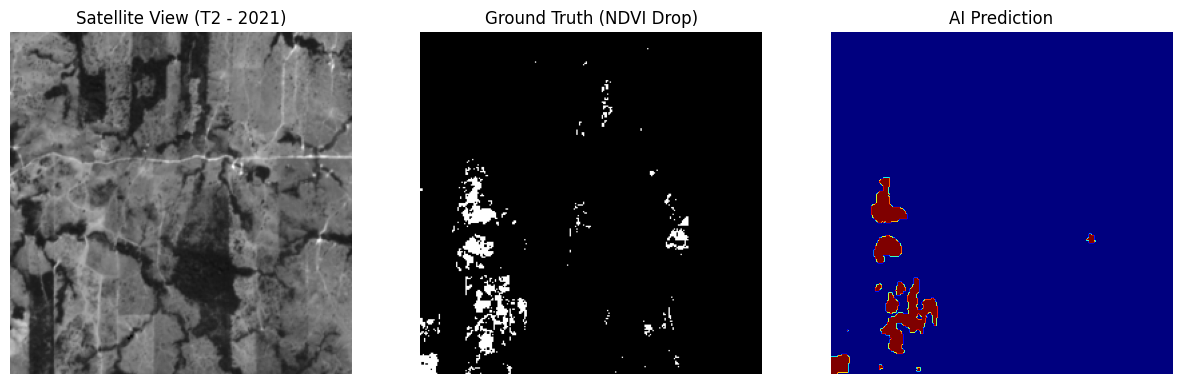

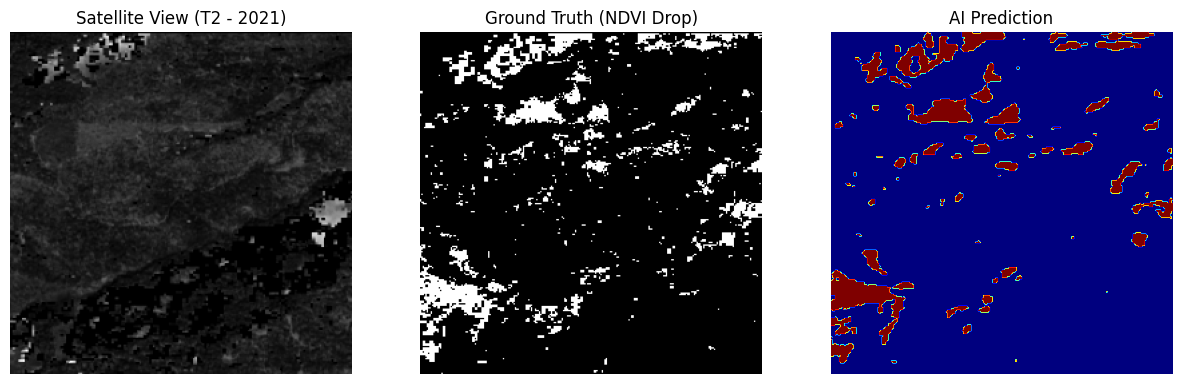

In [2]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_results(model, dataset, device, num_samples=5):
    model.eval() # Set to evaluation mode
    
    # Randomly pick samples from validation set
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for idx in indices:
        image, mask = dataset[idx]
        
        # Prepare input
        input_tensor = image.unsqueeze(0).to(device) # Add batch dim
        
        # Inference
        with torch.no_grad():
            output = model(input_tensor)
            # Convert Logits -> Probability (0-1) -> Binary Mask (0 or 1)
            pred_mask = (torch.sigmoid(output) > 0.5).float()
        
        # Move to CPU for plotting
        # Image structure: 10 channels. 
        # T1 (2019) is 0-4. T2 (2021) is 5-9.
        # Let's look at the RED band of T2 (Index 7) to see the ground clearly.
        # (B2, B3, B4, B8, B11) -> B4 (Red) is index 2 (T1) and 7 (T2).
        t2_red_band = image[7, :, :].cpu().numpy()
        
        true_mask = mask[0, :, :].cpu().numpy()
        pred_mask = pred_mask[0, 0, :, :].cpu().numpy()

        # --- PLOTTING ---
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # 1. The Satellite Image (T2 Red Band)
        axes[0].imshow(t2_red_band, cmap='gray')
        axes[0].set_title(f"Satellite View (T2 - 2021)")
        axes[0].axis('off')
        
        # 2. The Ground Truth (What the math calculated)
        axes[1].imshow(true_mask, cmap='gray')
        axes[1].set_title("Ground Truth (NDVI Drop)")
        axes[1].axis('off')
        
        # 3. The Prediction (What the AI thinks)
        axes[2].imshow(pred_mask, cmap='jet', alpha=1.0) # 'jet' makes 0 blue, 1 red
        axes[2].set_title("AI Prediction")
        axes[2].axis('off')
        
        plt.show()

# --- RUN IT ---
# Load the best model
model = smp.Unet(
    encoder_name=ENCODER, 
    in_channels=10, 
    classes=1, 
    activation=None
)
# Load weights from the saved file
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.to(DEVICE)

# Load validation set again
val_dataset = ChangeDetectionDataset(DATA_DIR, split="val")

# Visualize!
visualize_results(model, val_dataset, DEVICE, num_samples=5)

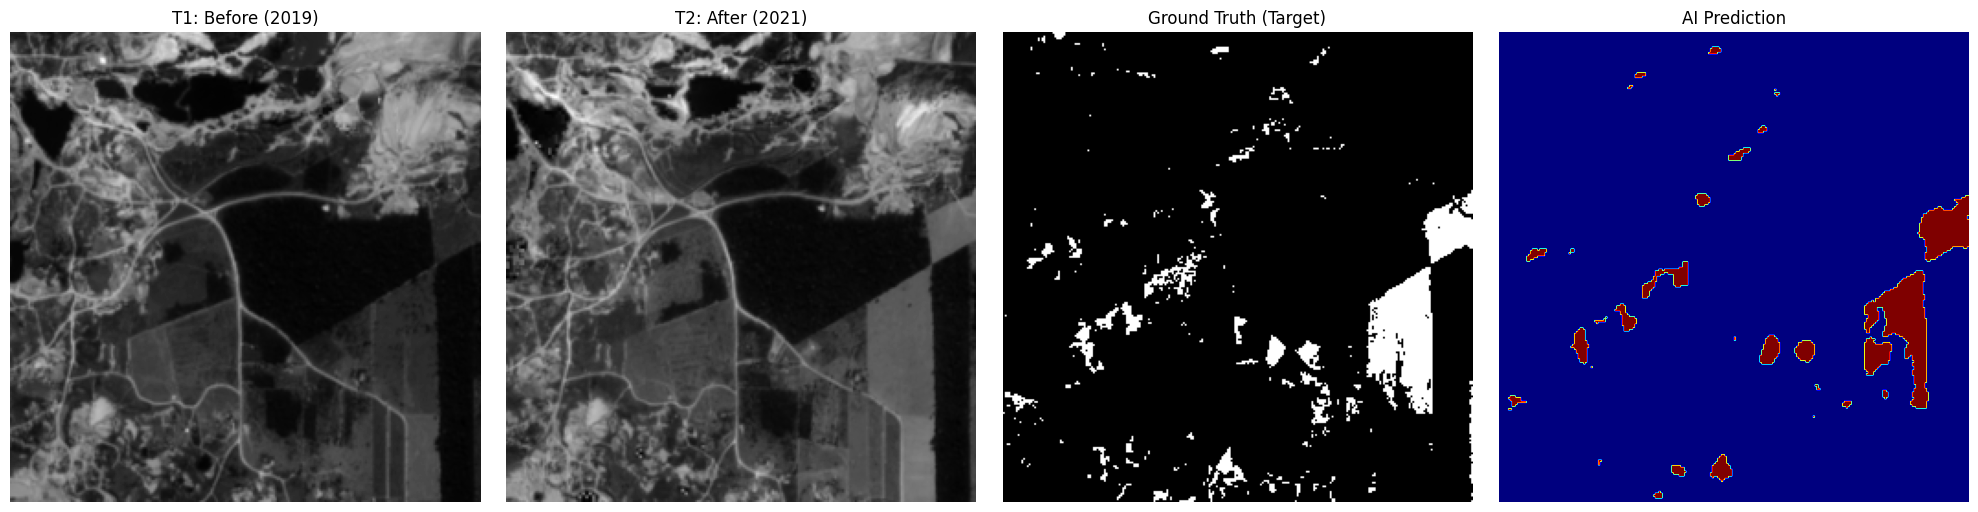

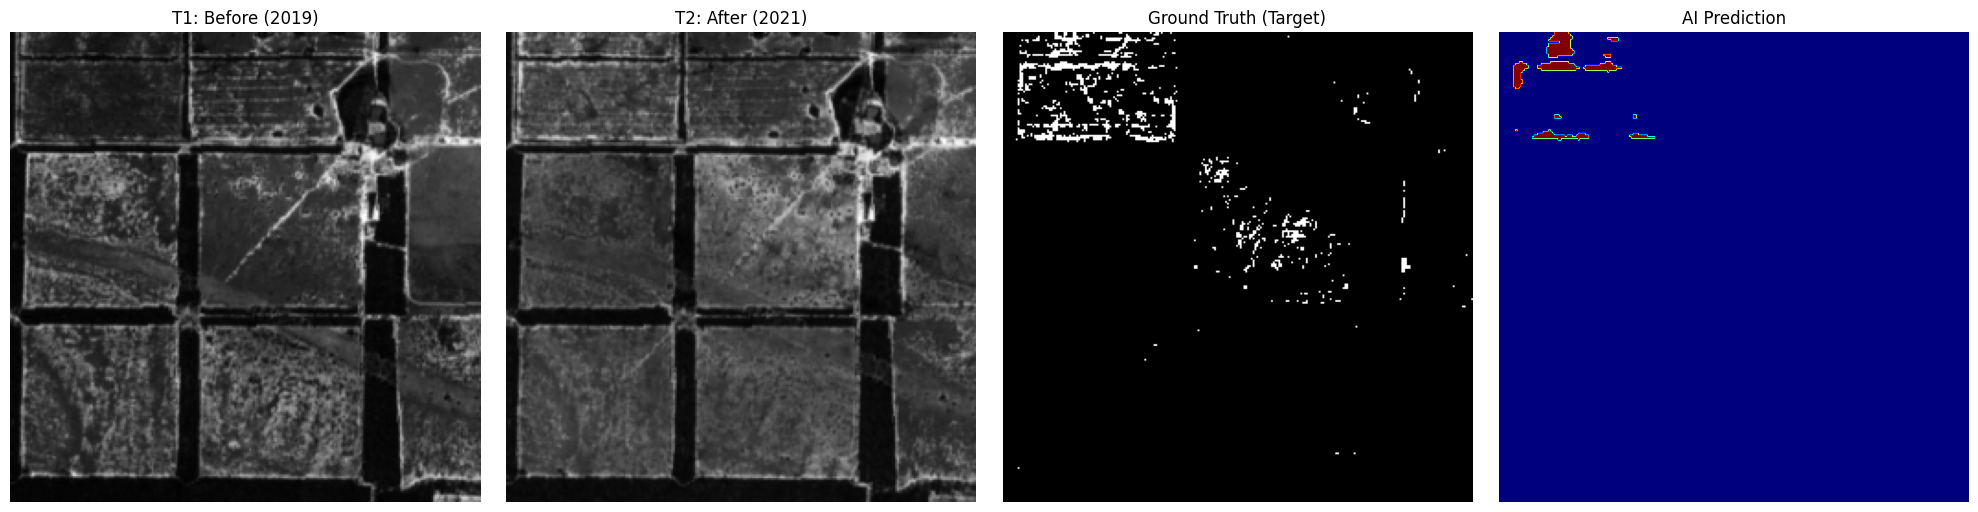

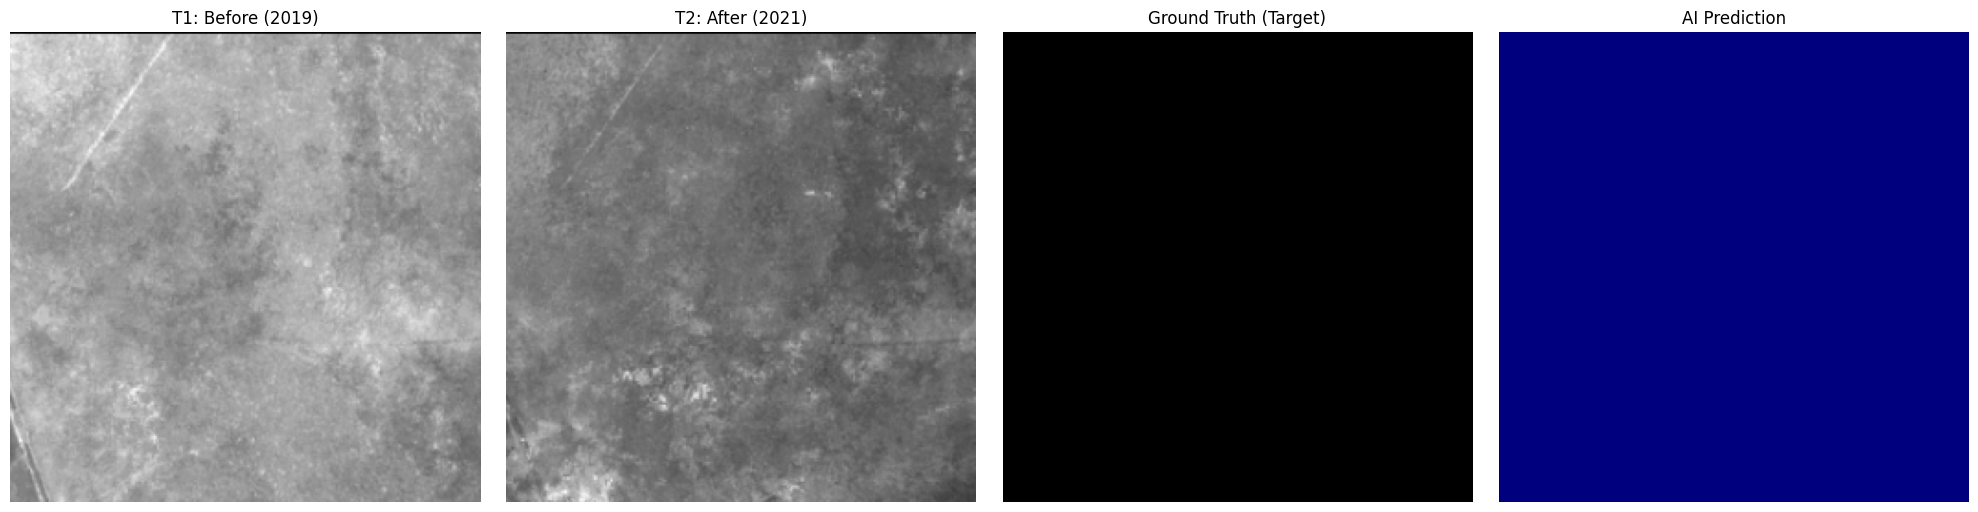

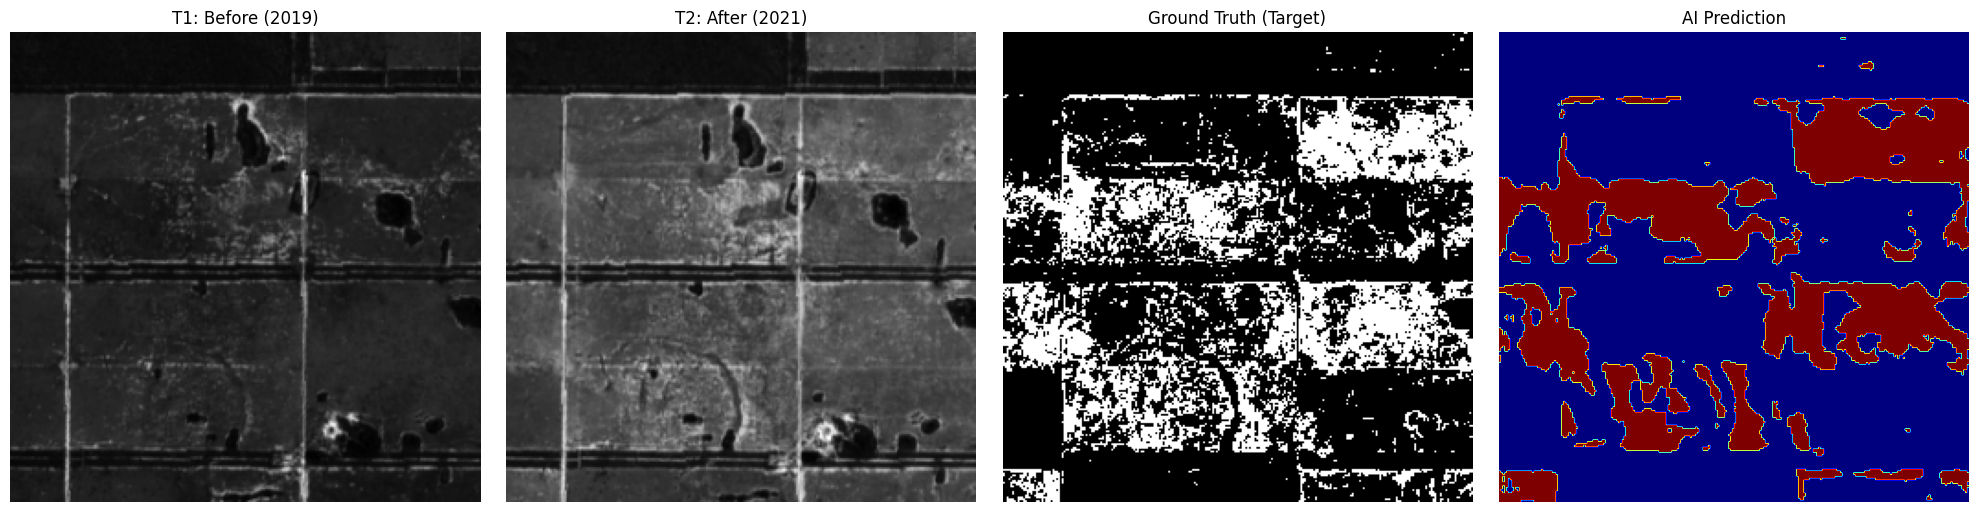

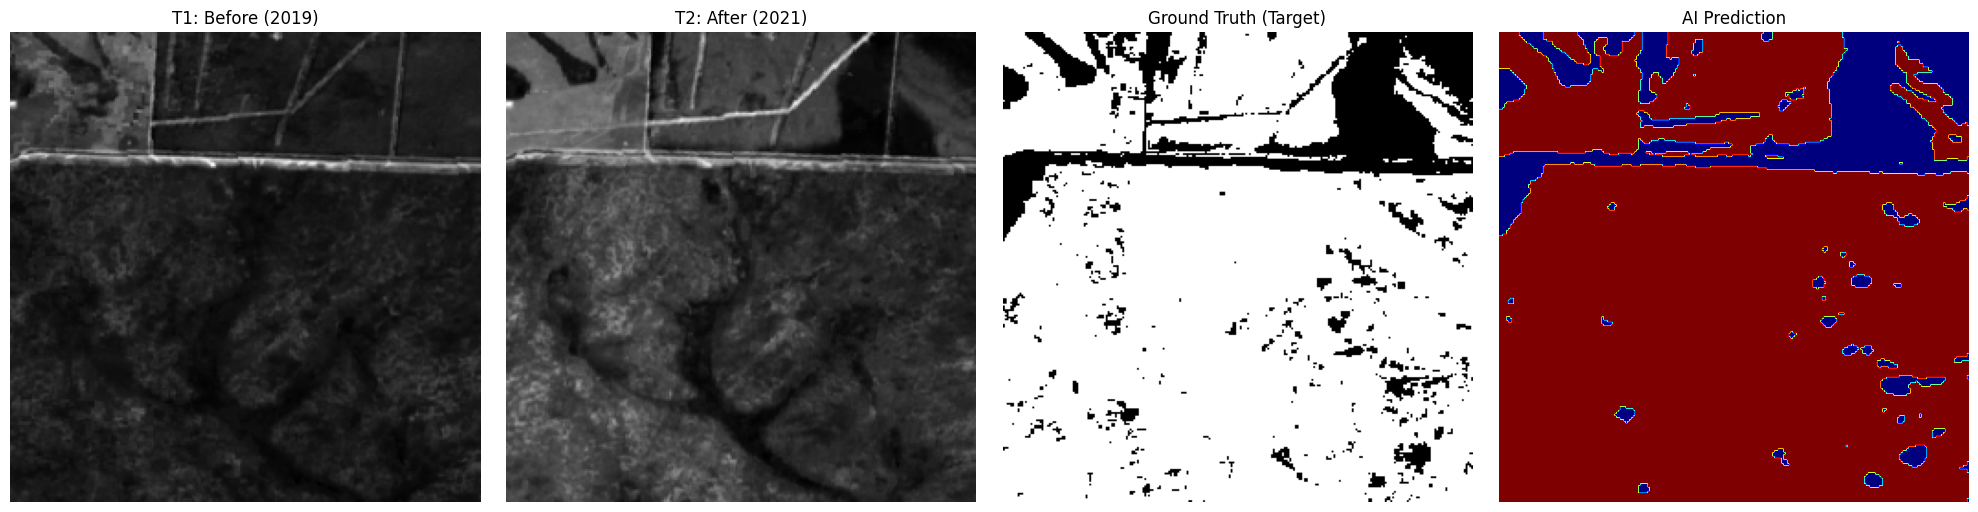

In [3]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_full_comparison(model, dataset, device, num_samples=5):
    model.eval()
    
    # Randomly pick samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for idx in indices:
        image, mask = dataset[idx]
        
        # Prepare input
        input_tensor = image.unsqueeze(0).to(device)
        
        # Inference
        with torch.no_grad():
            output = model(input_tensor)
            pred_mask = (torch.sigmoid(output) > 0.5).float()
        
        # --- EXTRACT BANDS FOR VISUALIZATION ---
        # Image is (10, H, W)
        # T1 (2019): Channels 0-4 -> Red is Index 2
        # T2 (2021): Channels 5-9 -> Red is Index 7
        
        t1_red = image[2, :, :].cpu().numpy()
        t2_red = image[7, :, :].cpu().numpy()
        
        true_mask = mask[0, :, :].cpu().numpy()
        pred_mask = pred_mask[0, 0, :, :].cpu().numpy()

        # --- PLOTTING (4 Columns) ---
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # 1. T1 (Before)
        axes[0].imshow(t1_red, cmap='gray')
        axes[0].set_title(f"T1: Before (2019)")
        axes[0].axis('off')

        # 2. T2 (After)
        axes[1].imshow(t2_red, cmap='gray')
        axes[1].set_title(f"T2: After (2021)")
        axes[1].axis('off')
        
        # 3. Ground Truth
        axes[2].imshow(true_mask, cmap='gray')
        axes[2].set_title("Ground Truth (Target)")
        axes[2].axis('off')
        
        # 4. AI Prediction
        axes[3].imshow(pred_mask, cmap='jet') 
        axes[3].set_title("AI Prediction")
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()

# --- RUN IT ---
# (Assuming 'model' and 'val_dataset' are already loaded from previous cell)
visualize_full_comparison(model, val_dataset, DEVICE, num_samples=5)

In [4]:
!zip -r all_output.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/training_plot.png (deflated 9%)
  adding: kaggle/working/best_model.pth (deflated 7%)


In [5]:
from IPython.display import FileLink
FileLink(r'all_output.zip')

/kaggle/working/all_output.zip

 Evaluating on 103 validation images...

    FINAL EVALUATION RESULTS   
Overall Accuracy:  94.82%
IoU (Intersection over Union): 0.8340
F1 Score:          0.9095
Precision:         0.9192
Recall:            0.9000


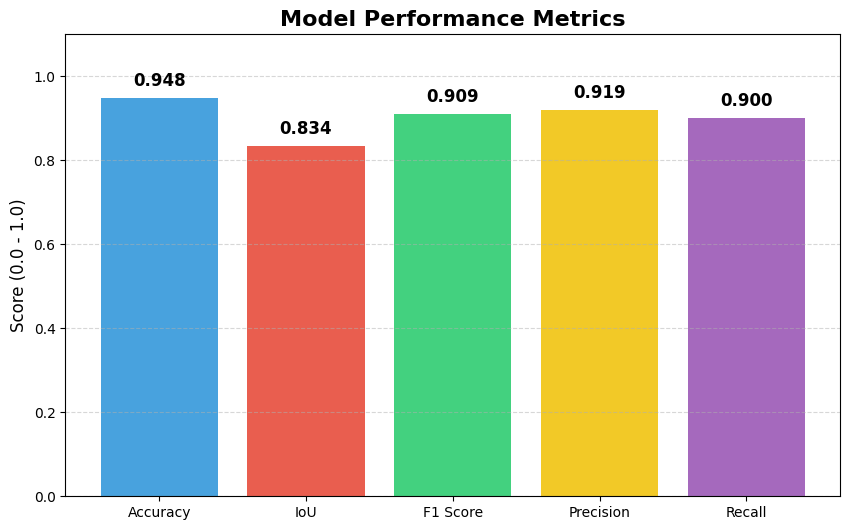

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, jaccard_score, precision_score, recall_score, f1_score
import torch
from torch.utils.data import DataLoader

def evaluate_and_plot():
    # --- CONFIG ---
    MODEL_PATH = "/kaggle/working/best_model.pth"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 1. Load Validation Data
    # Reuses the ChangeDetectionDataset class you defined earlier
    val_dataset = ChangeDetectionDataset(DATA_DIR, split="val") 
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

    # 2. Load Model Architecture & Weights
    model = smp.Unet(encoder_name=ENCODER, in_channels=10, classes=1, activation=None)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    print(f" Evaluating on {len(val_dataset)} validation images...")
    
    # 3. Run Inference
    all_preds = []
    all_masks = []
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            
            # Convert logits to binary (0 or 1)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy().flatten()
            masks = masks.cpu().numpy().flatten()
            
            all_preds.extend(preds)
            all_masks.extend(masks)

    # 4. Calculate Metrics
    # Cast to int for sklearn
    y_true = np.array(all_masks, dtype=int)
    y_pred = np.array(all_preds, dtype=int)

    acc = accuracy_score(y_true, y_pred)
    iou = jaccard_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)

    # 5. Print Report
    print("\n" + "="*30)
    print("    FINAL EVALUATION RESULTS   ")
    print("="*30)
    print(f"Overall Accuracy:  {acc*100:.2f}%")
    print(f"IoU (Intersection over Union): {iou:.4f}")
    print(f"F1 Score:          {f1:.4f}")
    print(f"Precision:         {prec:.4f}")
    print(f"Recall:            {rec:.4f}")
    print("="*30)

    # 6. Plot Bar Chart
    metrics = ['Accuracy', 'IoU', 'F1 Score', 'Precision', 'Recall']
    values = [acc, iou, f1, prec, rec]
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#9b59b6']

    plt.figure(figsize=(10, 6))
    bars = plt.bar(metrics, values, color=colors, alpha=0.9)
    plt.ylim(0, 1.1)
    plt.title('Model Performance Metrics', fontsize=16, fontweight='bold')
    plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add numbers on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.show()

# Run it
evaluate_and_plot()